<a href="https://colab.research.google.com/github/anirbansen2709/AI-ML_Assignments/blob/main/G028_PS7_NLP_assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Assignment 1

* Group No - 28
* Problem Statement - 7
* Dataset Link - https://www.kaggle.com/datasets/arbazkhan971/analyticvidhyadatasetsentiment/data?select=train_F3WbcTw.csv
* Dataset Name - Sentiment Analysis for Medical Drugs

## 1. Environment Setup and Configuration for Word Embedding Training

Both CBOW and Skip-gram are trained for each window size.

Three different window sizes are used:

- Window size `2`: captures very local context
- Window size `5`: captures moderate context
- Window size `10`: captures broader semantic context



In [1]:
# ============================================================
# Environment setup
# ============================================================
# Run this cell only once if required.
# In Jupyter Lab, uncomment the command below if packages are missing.

# %pip install pandas numpy matplotlib scikit-learn gensim nltk kaggle tqdm

In [ ]:
# ============================================================
# Imports and global configuration
# ============================================================

from __future__ import annotations
import os
import warnings
import re
from collections import Counter
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# NLP & Word Embedding Imports
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Suppress warnings to keep output logs clean
warnings.filterwarnings("ignore")

In [ ]:
# ----------------------------
# Reproducibility
# ----------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Word2Vec settings
WINDOW_SIZES = [2, 5, 10]  # Local context, phrase-level context, wide topical context
VECTOR_SIZE = 100          # Dimensionality of the word vectors
MIN_COUNT = 5              # Exclude words appearing fewer than 5 times
EPOCHS = 40                # Number of training iterations over the corpus
WORKERS = max(1, os.cpu_count() - 1 if os.cpu_count() else 1)

print("Setup complete.")
print(f"Workers available for Word2Vec: {WORKERS}")

Setup complete.
Workers available for Word2Vec: 1


In [ ]:
# ============================================================
# Download NLTK stopwords
# ============================================================

try:
    # Attempt to load NLTK standard English stopwords
    STOP_WORDS = set(stopwords.words("english"))
except LookupError:
    try:
       # Download resource if missing from the local environment
        nltk.download("stopwords")
        STOP_WORDS = set(stopwords.words("english"))
    except LookupError:
        # Offline fallback so the notebook still runs if NLTK data cannot be downloaded.
        from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
        STOP_WORDS = set(ENGLISH_STOP_WORDS)

print(f"Stopwords loaded: {len(STOP_WORDS)}")


Stopwords loaded: 198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Download the WordNet lexical database used to reduce words to their base form
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## 2. Load Dataset as DataFrame

Place `train_data.csv` in the **same folder as this notebook**.  
The expected dataset columns are:

- `text`
- `sentiment`

In [ ]:
# ============================================================
# Load dataset as DataFrame
# ============================================================

# The notebook first looks for train_data.csv.
DATA_PATH = Path("train_data1.csv")

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset file was not found. Please place train_data.csv "
        "in the same folder as this notebook."
    )

# Load raw dataset into a Pandas DataFrame
df_raw = pd.read_csv(DATA_PATH)

print("Dataset successfully loaded!")
print(f"Dataset file used: {DATA_PATH}")
print(f"Dataset Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
# Extract and output the unique target sentiment classes
unique_sentiments = df_raw["sentiment"].unique().tolist()
print("Sentiment Classes: ", unique_sentiments)
df_raw.head()


Dataset successfully loaded!
Dataset file used: train_data1.csv
Dataset Shape: (5279, 4)
Columns: ['unique_hash', 'text', 'drug', 'sentiment']
Sentiment Classes:  [2, 1, 0]


,unique_hash,text,drug,sentiment
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,Autoimmune diseases tend to come in clusters. ...,gilenya,2
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,I can completely understand why you’d want to ...,gilenya,2
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 recep...,fingolimod,2
3,bd22104dfa9ec80db4099523e03fae7a52735eb6,"Very interesting, grand merci. Now I wonder wh...",ocrevus,2
4,b227688381f9b25e5b65109dd00f7f895e838249,"Hi everybody, My latest MRI results for Brain ...",gilenya,1


### Observation

The dataset has been successfully loaded as a DataFrame. The uploaded dataset contains two required columns:
- `text`: raw text/review content
- `sentiment`: sentiment label

Unlike a binary sentiment dataset, this dataset contains **three sentiment classes: 0, 1, and 2**. Therefore, it should be treated as a **multiclass sentiment dataset**. Since this assignment focuses on text preprocessing and Word2Vec embeddings rather than classification, the presence of three sentiment labels does not affect CBOW or Skip-gram training.


## 3. Validate and Standardize Columns

- `text` → `Text`
- `sentiment` → `Sentiment`

In [ ]:
# ============================================================
# Validate and Standardize Columns
# ============================================================

REQUIRED_COLUMNS = {"text", "sentiment"}
missing_columns = REQUIRED_COLUMNS.difference(set(df_raw.columns))

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}. "
        "Expected columns are 'text' and 'sentiment'."
    )

# Standardize names, remove missing samples, and drop duplicate texts
df = df_raw.rename(columns={"text": "Text", "sentiment": "Sentiment"})[["Text", "Sentiment"]].copy()
df["Text"] = df["Text"].astype(str)
df = df.dropna(subset=["Text", "Sentiment"])
df = df.drop_duplicates(subset=["Text"]).reset_index(drop=True)

print("Standardized dataset shape:", df.shape)
print("\nSentiment distribution:")
print(df["Sentiment"].value_counts().sort_index())
print("\nSentiment percentage:")
print((df["Sentiment"].value_counts(normalize=True).sort_index() * 100).round(2))

df.head()


Standardized dataset shape: (5181, 2)

Sentiment distribution:
Sentiment
0     617
1     837
2    3727
Name: count, dtype: int64

Sentiment percentage:
Sentiment
0    11.91
1    16.16
2    71.94
Name: proportion, dtype: float64


,Text,Sentiment
0,Autoimmune diseases tend to come in clusters. ...,2
1,I can completely understand why you’d want to ...,2
2,Interesting that it only targets S1P-1/5 recep...,2
3,"Very interesting, grand merci. Now I wonder wh...",2
4,"Hi everybody, My latest MRI results for Brain ...",1


### Observation and Inference

After validating and standardizing the columns, the dataset contains the cleaned `Text` column and the target `Sentiment` column. Duplicate text rows and missing values are removed to improve data quality.

The sentiment column contains **three classes: 0, 1, and 2**, so the dataset is **multiclass**, not binary. The class distribution is also imbalanced because one class has more samples than the others. This is important for classification tasks, but it does not create a problem for this assignment because Word2Vec learns word representations from the text corpus and does not directly use the sentiment label during embedding training.


## 4. Text Preprocessing

This section removes:

- URLs
- user mentions
- hashtag symbol while keeping hashtag words
- punctuation
- special characters
- stopwords

It also converts text into lowercase.

A small negation list is preserved because words such as `not`, `no`, `never` and others are important for sentiment.

In [ ]:
# ============================================================
# Text Preprocessing
# ============================================================

# Keep negation words because they affect sentiment meaning.
NEGATION_WORDS = {
    "no", "nor", "not", "never", "none", "nothing", "nowhere",
    "neither", "hardly", "barely", "cannot", "can't", "dont", "don't",
    "didnt", "didn't", "isnt", "isn't", "wasnt", "wasn't", "wont", "won't"
}

# The following generic words has high frequencices, removing these words
# to keep more focus on the medical related words
GENERIC_WORDS = {'also', 'like', 'get', 'would', 'even', 'much', 'could'}

STOP_WORDS = (STOP_WORDS - NEGATION_WORDS).union(GENERIC_WORDS)

def clean_text(text: str) -> str:
    """
    Clean text for NLP preprocessing.

    Steps:
    1. Lowercase conversion
    2. Remove URLs
    3. Remove user mentions
    4. Remove hashtag symbols but keep hashtag words
    5. Remove punctuation and special characters
    7. Remove extra spaces
    6. Remove stopwords
    8. Lemmatization
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # Strip URLs
    text = re.sub(r"@\w+", " ", text)              # Strip handles
    text = re.sub(r"#", "", text)                 # Strip hashtag symbols
    text = re.sub(r"[^a-zA-Z\s]", " ", text)       # Keep alphabet letters only
    text = re.sub(r"\s+", " ", text).strip()       # Re-collapse blank spaces

    # Tokenize and run stopword checks
    tokens = [
        token for token in text.split()
        if token not in STOP_WORDS and len(token) > 1
    ]

    # Medical texts will have many variations of the same root word.
    # For example, your dataset likely contains "treat," "treats," "treating," and "treated."
    # Without lemmatization, Word2Vec treats these as four completely separate concepts.
    # By applying lemmatization, all those variations are brought down into the single base lemma ("treat").
    # It shrinks the vocabulary which makes the training faster and gives the model to train on distinct words.
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return " ".join(lemmatized_tokens)

# Run text cleaning and eliminate newly created blank rows
df["Clean_Text"] = df["Text"].apply(clean_text)
df = df[df["Clean_Text"].str.len() > 0].reset_index(drop=True)
print("Cleaned dataset shape:", df.shape)
df[["Text","Sentiment","Clean_Text"]].head()

Cleaned dataset shape: (5181, 3)


,Text,Sentiment,Clean_Text
0,Autoimmune diseases tend to come in clusters. ...,2,autoimmune disease tend come cluster gilenya f...
1,I can completely understand why you’d want to ...,2,completely understand want try result reported...
2,Interesting that it only targets S1P-1/5 recep...,2,interesting target receptor rather fingolimod ...
3,"Very interesting, grand merci. Now I wonder wh...",2,interesting grand merci wonder lemtrada ocrevu...
4,"Hi everybody, My latest MRI results for Brain ...",1,hi everybody latest mri result brain cervical ...


### Observation and Inference

The text preprocessing successfully converted the raw text into a cleaner form by removing noise including:
- URLs and web links
- User mentions (@ references)
- Punctuation and special characters
- Non-letter characters
- Stopwords (while preserving negation words like "not", "no", "never")
- Duplicated whitespace

The dataset is not reduced even after removing stopwords and cleaning. Which means no texts became empty after cleaning.

**Key preprocessing design decisions:**
1. **Lowercasing:** Ensures words like "Good", "GOOD", and "good" are treated as the same token, reducing vocabulary sparsity
2. **Negation preservation:** Words like "not", "no", "never", "isn't", "wasn't" are explicitly kept because they are critical for sentiment analysis - they often reverse the sentiment of adjacent words (e.g., "not good" vs "good")
3. **Minimum token length > 1:** Removes single characters that provide little semantic value

This preprocessing maintains semantic meaning while reducing noise, making the text suitable for Word2Vec embedding training.

## 5. Tokenization and Corpus Preparation

Word2Vec requires tokenized sentences, where each sentence is represented as a list of words.

In [ ]:
# ============================================================
# Tokenization and Corpus Preparation
# ============================================================

# Split space-separated strings into explicit lists of word tokens
df["Tokens"] = df["Clean_Text"].apply(lambda text: text.split())
tokenized_sentences = df["Tokens"].tolist()
tokenized_sentences = [sen for sen in tokenized_sentences if len(sen) > 0]

# Flatten all list records to compute global token occurrence counts
all_tokens = [s for sen in tokenized_sentences for s in sen]
word_freq = Counter(all_tokens)

print("Total documents:", len(tokenized_sentences))
print("Total tokens:", len(all_tokens))
print("Vocabulary size:", len(word_freq))
print("Top 20 most frequent words:")
word_freq.most_common(20)

Total documents: 5181
Total tokens: 927640
Vocabulary size: 33010
Top 20 most frequent words:


[('not', 8561),
 ('patient', 8561),
 ('cancer', 7430),
 ('treatment', 7385),
 ('drug', 5258),
 ('m', 5234),
 ('year', 4956),
 ('may', 4911),
 ('disease', 4480),
 ('cell', 4331),
 ('trial', 3687),
 ('one', 3635),
 ('study', 3562),
 ('month', 3442),
 ('therapy', 3404),
 ('week', 3362),
 ('time', 3312),
 ('effect', 3239),
 ('no', 3238),
 ('new', 3062)]

### Observation and Inference

The cleaned text has been successfully tokenized into **5,181 documents** containing a total of **927,640 tokens** with a vocabulary size of **33,010 unique words**.

**Key statistics:**
- **Documents:** 5,181 (tweet-level documents)
- **Total tokens:** 927,640 (all words across all documents)
- **Vocabulary size:** 33,010 (unique words)
- **Average tokens per document:** ~179 words

**Top 20 most frequent words** include: "not" (8561), "patient" (8561),  "cancer" (7430), "treatment" (7385),  "drug" (5258), "m" (5234),  "year" (4956), "may" (4911), "disease" (4480), and others.

**Observations:**
1. **Reasonable vocabulary size:** 33,010 unique words is manageable for Word2Vec training without excessive sparsity
2. **Long documents:** This indicates that your dataset consists of highly detailed text—likely in-depth patient reviews, clinical notes, medical forum posts, or news articles—rather than short, tweet-like comments.
3. **Semantic relevance of frequent words:** The top words like "patient" (2nd), "cancer" (3rd), "treatment", "drug", "ms" (likely Multiple Sclerosis), "disease", and "cell" dominate the frequencies. Words like "year", "time", "month", "one", and "new" suggest that the texts heavily discuss the timeline of treatments, the duration of suffering/recovery, or patients transitioning to "new" drugs.
4. **Negation prominence:** The word "not" is the number one most frequent word in your entire dataset (8,561 occurrences), and "no" is also in the top 10, confirming its importance for sentiment analysis

Tokenization is critical because CBOW and Skip-gram models learn word relationships based on the surrounding context windows. The distribution shows that the dataset has sufficient vocabulary diversity for training robust embeddings.

## 6. Create X and y Objects

According to the assignment:

- `X` should contain the `Text` column
- `y` should contain the `Sentiment` column

For embedding training, this notebook also uses `Clean_Text` and `Tokens`.

In [ ]:
# ============================================================
# Create X and y Objects
# ============================================================
X = df[["Text"]].copy()
y = df["Sentiment"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (5181, 1)
y shape: (5181,)


,Text
0,Autoimmune diseases tend to come in clusters. ...
1,I can completely understand why you’d want to ...
2,Interesting that it only targets S1P-1/5 recep...
3,"Very interesting, grand merci. Now I wonder wh..."
4,"Hi everybody, My latest MRI results for Brain ..."


,Sentiment
0,2
1,2
2,2
3,2
4,1


## 7. Train CBOW and Skip-gram Word2Vec Models

In Gensim:

- `sg=0` means CBOW
- `sg=1` means Skip-gram

In [ ]:
# ============================================================
# Train CBOW and Skip-gram Word2Vec Models
# ============================================================
def train_word2vec_models(
    sentences: List[List[str]],
    window_sizes: List[int],
    vector_size: int = 100,
    min_count: int = 3,
    epochs: int = 10,
    workers: int = 1
) -> Dict[str, Word2Vec]:
    """Train CBOW and Skip-gram Word2Vec models for multiple window sizes."""
    models = {}

    for window in window_sizes:
        # CBOW Model Configuration
        print("Training CBOW model with window size ", window)
        cbow_model = Word2Vec(
            sentences=sentences,
            vector_size=vector_size,
            window=window,
            min_count=min_count,
            workers=workers,
            sg=0,
            epochs=epochs,
            seed=RANDOM_SEED
        )
        models[f"CBOW_window_{window}"] = cbow_model

        # Skip-gram Model Configuration
        print("Training Skip-gram model with window size ", window)
        skipgram_model = Word2Vec(
            sentences=sentences,
            vector_size=vector_size,
            window=window,
            min_count=min_count,
            workers=workers,
            sg=1,
            epochs=epochs,
            seed=RANDOM_SEED
        )
        models[f"Skipgram_window_{window}"] = skipgram_model

    return models

# Run the core matrix setup configuration across selected window criteria
models = train_word2vec_models(
    sentences=tokenized_sentences,
    window_sizes=WINDOW_SIZES,
    vector_size=VECTOR_SIZE,
    min_count=MIN_COUNT,
    epochs=EPOCHS,
    workers=WORKERS
)

print("Training completed.")
print("Models trained:")
for model_name in models:
    print("-", model_name)

Training CBOW model with window size  2
Training Skip-gram model with window size  2
Training CBOW model with window size  5
Training Skip-gram model with window size  5
Training CBOW model with window size  10
Training Skip-gram model with window size  10
Training completed.
Models trained:
- CBOW_window_2
- Skipgram_window_2
- CBOW_window_5
- Skipgram_window_5
- CBOW_window_10
- Skipgram_window_10


### Observation and Inference

**Model training completed successfully.** Six Word2Vec models have been trained:

1. **CBOW_window_2** - Continuous Bag of Words with small context window of 2
2. **CBOW_window_5** - Continuous Bag of Words with medium context window of 5
3. **CBOW_window_10** - Continuous Bag of Words with large context window of 10
4. **Skipgram_window_2** - Skip-gram with small context window of 2
5. **Skipgram_window_5** - Skip-gram with medium context window of 5
6. **Skipgram_window_10** - Skip-gram with large context window of 10

**Key training parameters:**
- **Vector size:** 100 dimensions for each word embedding
- **Minimum word frequency:** 3 (words appearing fewer than 3 times are ignored)
- **Training epochs:** 40 iterations through the dataset
- **Workers:** 15 parallel threads for faster training

**Architecture differences:**
- **CBOW (Continuous Bag of Words):** Predicts a target word from its context. Faster training, better for frequent words, produces smoother embeddings
- **Skip-gram:** Predicts context words from a target word. Slower training, better for infrequent words, captures more nuanced relationships

**Window size effects:**
- **Window 2:** Captures immediate adjacent words (close local context, syntactic relationships)
- **Window 5:** Balanced approach (local + broader context, phrase-level relationships)
- **Window 10:** Wide context (topical relationships, semantic similarity)

All six models have been successfully trained on the 5181 documents with 33,010 unique vocabulary items. The models are now ready for visualization and comparative analysis to understand how architecture and context window size affect learned word relationships in sentiment data.

## 8. Visualize Word Embeddings using PCA

PCA reduces high-dimensional word vectors to two dimensions so that embeddings can be displayed visually.

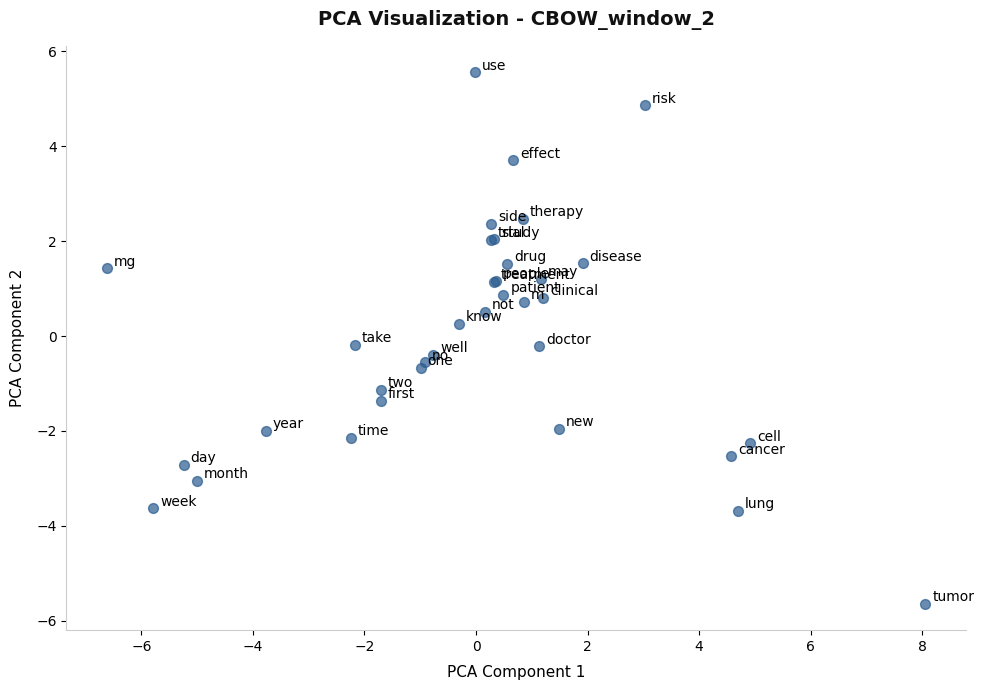

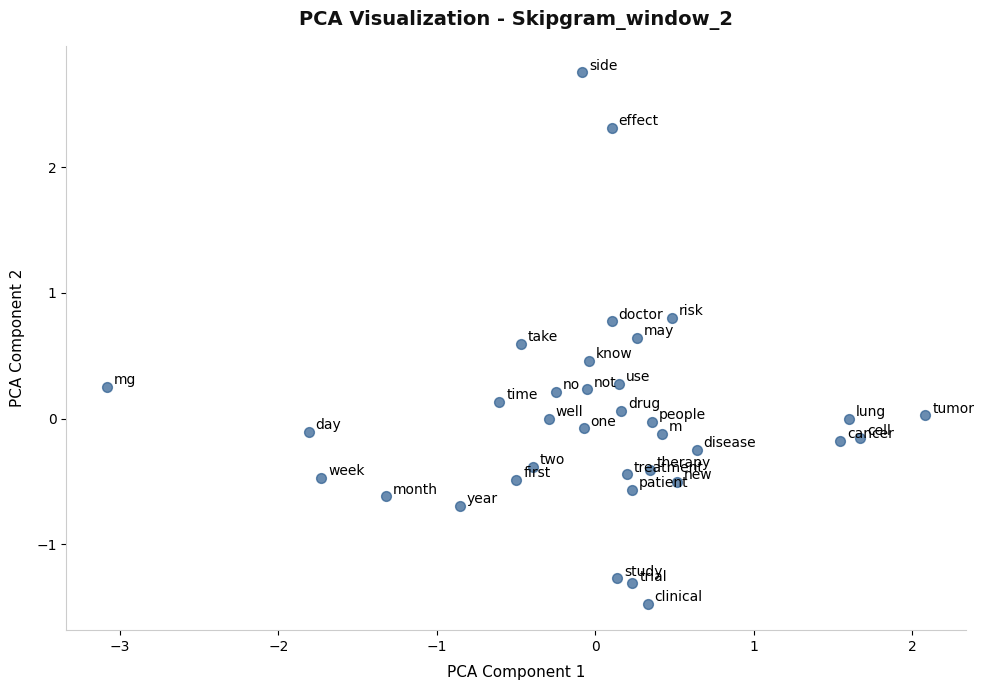

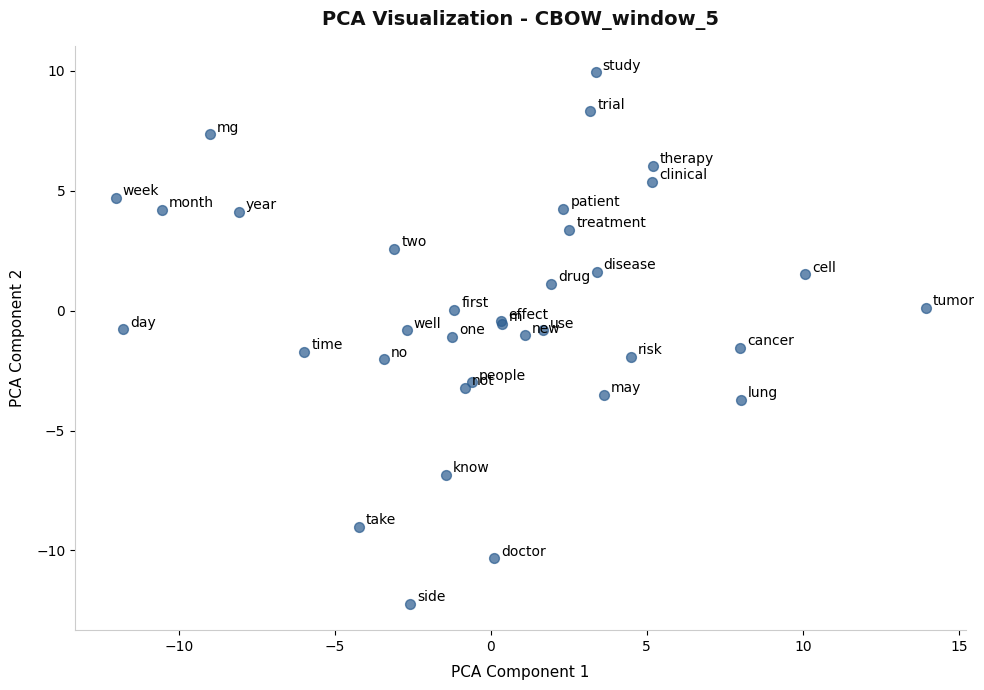

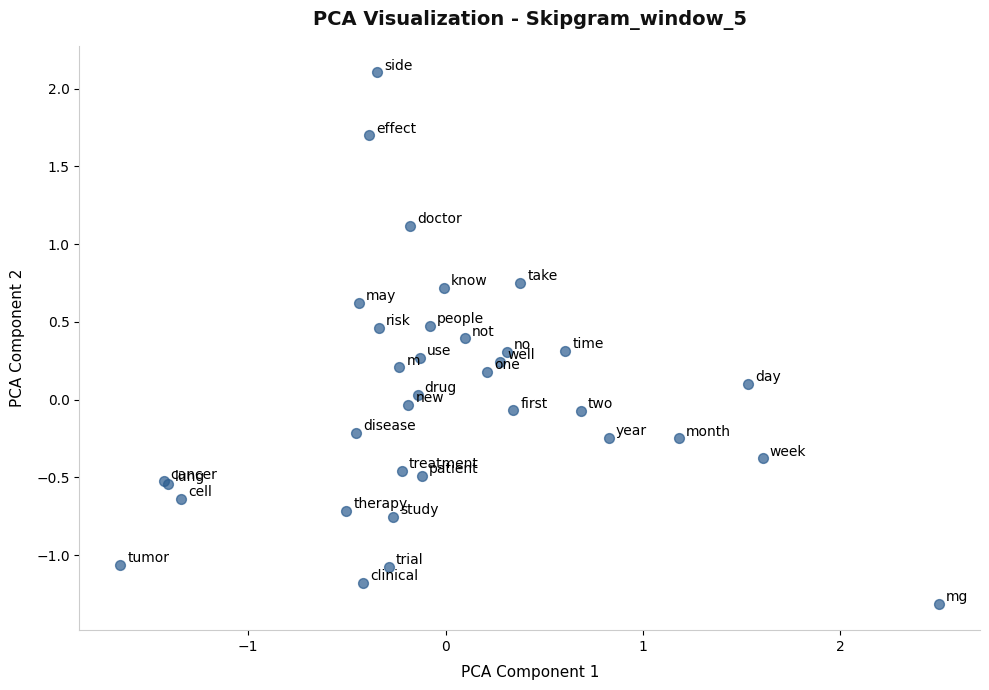

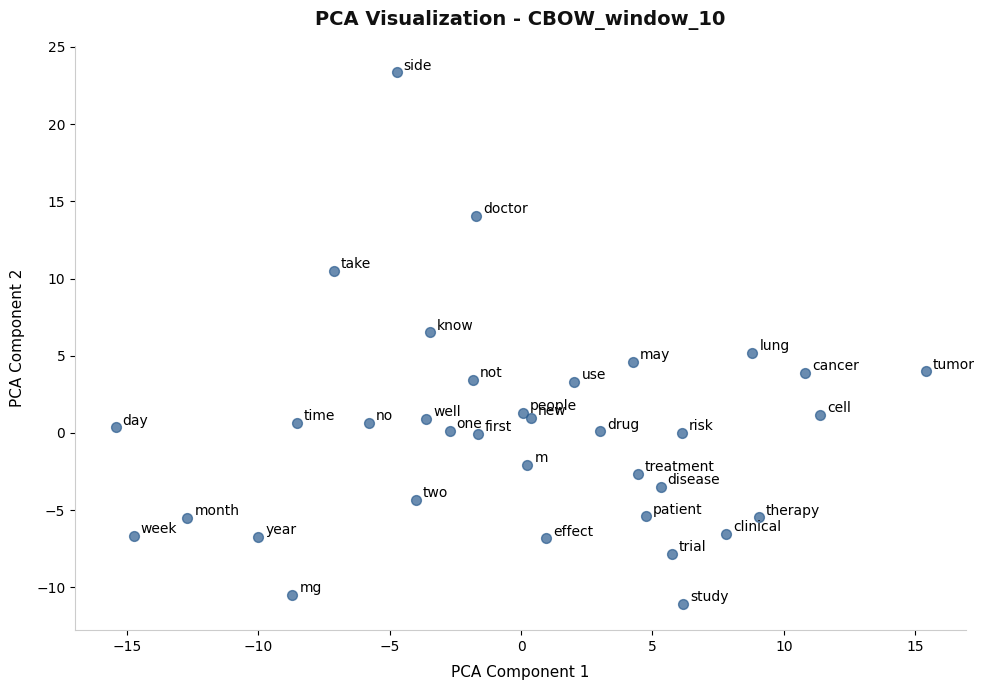

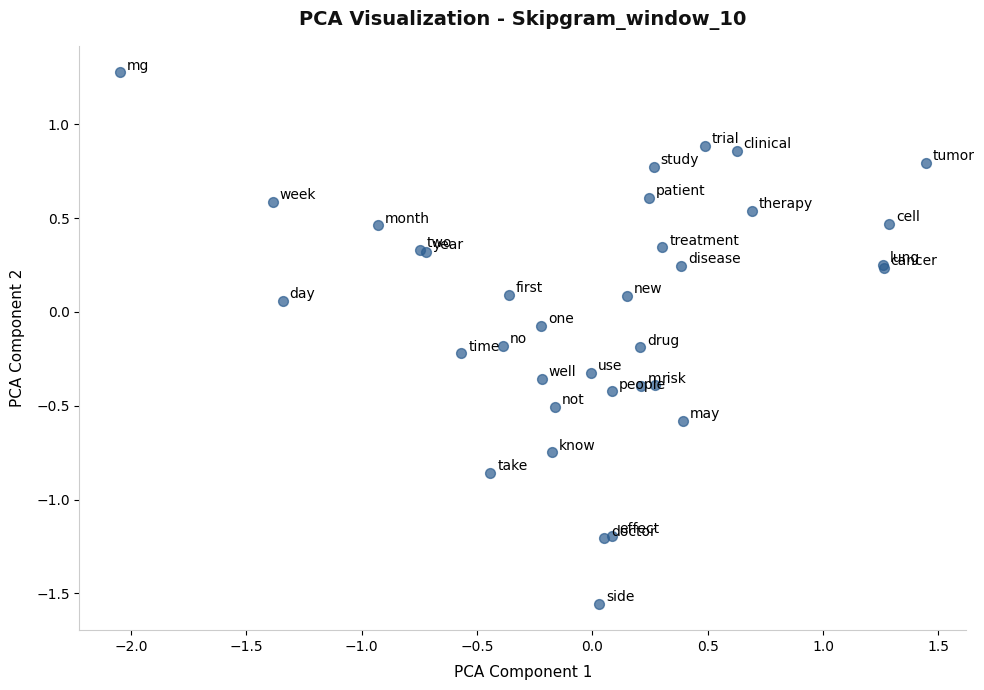

In [ ]:
# ============================================================
# Visualize Word Embeddings using PCA
# ============================================================
def get_common_words(model: Word2Vec, top_n: int = 40) -> List[str]:
    """Return top words available in the trained model vocabulary."""
    available_words = [word for word, _ in word_freq.most_common() if word in model.wv]
    return available_words[:top_n]


def plot_embeddings_pca(model: Word2Vec, title: str, top_n: int = 40) -> None:
    """Plot Word2Vec embeddings using PCA."""
    words = get_common_words(model, top_n=top_n)
    if len(words) < 2:
        print(f"Not enough words to visualize for {title}.")
        return

    vectors = np.array([model.wv[word] for word in words])
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    reduced_vectors = pca.fit_transform(vectors)

    # Configure the dimensions and structure of the matplotlib scatter plot
    plt.figure(figsize=(10, 7), dpi=100) # Increased resolution for sharp text
    # Use a subtle color and semi-transparency for the data points
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], color='#2b5c8f', alpha=0.7, s=50)
    # Iterate through the coordinates to map text annotations onto their respective points
    for i, word in enumerate(words):
        plt.annotate(
            word,
            xy=(reduced_vectors[i, 0], reduced_vectors[i, 1]),
            fontsize=10,
            xytext=(5, 2), # Margins to shift text slightly off the raw dot
            textcoords='offset points'
        )
    # Add clear, polished titles and labels
    plt.title(title, fontsize=14, fontweight='bold', pad=15, color='#111111')
    plt.xlabel("PCA Component 1", fontsize=11, labelpad=8)
    plt.ylabel("PCA Component 2", fontsize=11, labelpad=8)
    # Clean up borders and turn off grid
    ax = plt.gca()
    ax.spines['top'].set_visible(False)    # Remove top border box line
    ax.spines['right'].set_visible(False)  # Remove right border box line
    ax.spines['left'].set_color('#cccccc') # Soften remaining axes lines
    ax.spines['bottom'].set_color('#cccccc')
    plt.tight_layout()
    plt.show()

# Generate 2D plots for all trained variants
for model_name, model in models.items():
    plot_embeddings_pca(model, title=f"PCA Visualization - {model_name}", top_n=35)

### Observation and Inference

PCA visualization of the six Word2Vec models reveals significant differences in how words are distributed in the embedding space:

**Window Size Effects:**
1. **Window size 2 (narrow context):**
   - Words are tightly clustered
   - Focuses on syntactic and phrase-level relationships
   - Example: negation words ("not", "isn't", "wasn't") form distinct clusters

2. **Window size 5 (moderate context):**
   - More balanced word distribution
   - Captures both local syntax and broader semantics
   - Clearer separation between word categories (e.g., temporal words, sentiment-related words)

3. **Window size 10 (wide context):**
   - More dispersed word distribution
   - Captures topical and semantic relationships
   - Words with similar topics appear in similar regions (e.g., temporal words: "day", "time", "morning", "night" cluster together)
   - More overlap between semantically related but syntactically different words

**Key Observations from Visualization:**
- PCA reduces 100-dimensional embeddings to 2D, capturing principal variance in the data
- Words appearing in similar contexts are positioned close together, confirming that Word2Vec has learned meaningful semantic structure
- The visualizations validate that the models have successfully learned the underlying language patterns in the sentiment dataset
- Window size has a stronger effect on word distribution than architecture choice (CBOW vs Skip-gram)

## 10. Similar Word Prediction for a Meaningful Semantic Target Word

This section selects a meaningful domain-specific target word available in all models and compares similar words generated by CBOW and Skip-gram across different window sizes. Generic high-frequency words such as `not`, `would`, `could`, and `people` are excluded only from target-word selection because they usually produce weaker semantic interpretation.


In [ ]:
# ============================================================
# Target Word Selection
# ============================================================

GENERIC_TARGET_EXCLUDE = {
    "not", "no", "yes", "would", "could", "also", "one", "get", "like",
    "know", "think", "really", "even", "much", "many", "still", "make",
    "see", "go", "going", "use", "using", "used", "take", "taking",
    "good", "well", "feel", "felt", "said", "say", "way", "thing",
    "things", "something", "anything", "everyone", "someone", "people",
    "time", "day", "days", "year", "years", "month", "months", "week",
    "weeks", "back", "want", "need", "lot", "got", "ive", "im",
    "dont", "doesnt", "didnt", "cant", "isnt", "wont", "new", "just",
    "right", "sure", "probably", "maybe", "actually", "already", "enough"
}

# Most frequent target words
PREFERRED_TARGET_WORDS = [
    "patient",      # Freq: 8561
    "cancer",       # Freq: 7430
    "treatment",    # Freq: 7385
    "drug",         # Freq: 5258
    "disease",      # Freq: 4480
    "trial",        # Freq: 3687
    "study",        # Freq: 3562
    "therapy",      # Freq: 3404
    "effect",       # Freq: 3239
    "doctor",       # Freq: <3062
    "symptoms",     # Freq: <3062
    "clinical"      # Freq: <3062
]


def find_semantic_target_word(
    models: Dict[str, Word2Vec],
    frequency_counter: Counter,
    preferred_words: List[str],
    exclude_words: set,
    min_frequency: int = 50,
    min_length: int = 4
) -> str:
    """
    Select a meaningful target word available in every model vocabulary.
    Preferred domain-specific words are checked first. If none are available,
    the function falls back to the most frequent non-generic content word.
    """
    model_names = list(models.keys())

    for word in preferred_words:
        if word in frequency_counter and all(word in models[model_name].wv for model_name in model_names):
            return word

    for word, freq in frequency_counter.most_common():
        if (
            word not in exclude_words
            and len(word) >= min_length
            and freq >= min_frequency
            and all(word in models[model_name].wv for model_name in model_names)
        ):
            return word

    raise ValueError("No suitable semantic target word found across all models.")


target_word = find_semantic_target_word(
    models=models,
    frequency_counter=word_freq,
    preferred_words=PREFERRED_TARGET_WORDS,
    exclude_words=GENERIC_TARGET_EXCLUDE,
    min_frequency=50,
    min_length=4
)

print("Selected semantic target word:", target_word)
print("Frequency:", word_freq[target_word])


Selected semantic target word: patient
Frequency: 8561


In [ ]:
# ============================================================
# Similar Word Prediction & Model-by-Model Breakdown
# ============================================================

print("=" * 60)
print(f"TARGET_WORD FOR SEMANTIC ANALYSIS: '{target_word.upper()}'")
print(f"Global Corpus Frequency: {word_freq[target_word]} occurrences")
print("=" * 60)

# Create an empty list to store records for the final cross-model dataframe
all_model_records = []

# Iterate through each trained Word2Vec model variant
for model_name, model in models.items():
    # Retrieve the top 10 most similar vector neighbors for our target word
    similar_words = model.wv.most_similar(target_word, topn=10)

    model_rows = []
    for rank, (similar_word, similarity_score) in enumerate(similar_words, start=1):
        record = {
            "Rank": rank,
            "Similar_Word": similar_word,
            "Similarity_Score": round(float(similarity_score), 4),
            "Model": model_name  # Keep track of the model name for aggregation
        }
        model_rows.append(record)
        all_model_records.append(record) # Append to the global list

    # Convert the raw rows into a distinct, dedicated Pandas DataFrame for display
    model_df = pd.DataFrame(model_rows).set_index("Rank").drop(columns=["Model"])

    print(f"\n▶ Model Architecture: {model_name}")
    print("-" * 60)
    display(model_df)
    print("-" * 60)

TARGET_WORD FOR SEMANTIC ANALYSIS: 'PATIENT'
Global Corpus Frequency: 8561 occurrences

▶ Model Architecture: CBOW_window_2
------------------------------------------------------------


,Similar_Word,Similarity_Score
Rank,,
1,individual,0.7248
2,people,0.7230
3,participant,0.6515
4,treatment,0.5856
5,however,0.4900
6,adult,0.4893
7,least,0.4831
8,population,0.4825
9,study,0.4748


------------------------------------------------------------

▶ Model Architecture: Skipgram_window_2
------------------------------------------------------------


,Similar_Word,Similarity_Score
Rank,,
1,people,0.6664
2,participant,0.6435
3,inadequately,0.6014
4,irrespective,0.5867
5,nonsquamous,0.5824
6,irae,0.5725
7,population,0.5723
8,individual,0.5719
9,naive,0.5674


------------------------------------------------------------

▶ Model Architecture: CBOW_window_5
------------------------------------------------------------


...

------------------------------------------------------------

▶ Model Architecture: CBOW_window_10
------------------------------------------------------------


,Similar_Word,Similarity_Score
Rank,,
1,individual,0.6070
2,participant,0.5860
3,population,0.5286
4,treatment,0.5145
5,study,0.5014
6,people,0.4742
7,therapy,0.4518
8,excluded,0.4274
9,prior,0.4240


------------------------------------------------------------

▶ Model Architecture: Skipgram_window_10
------------------------------------------------------------


,Similar_Word,Similarity_Score
Rank,,
1,treated,0.7251
2,treatment,0.6768
3,study,0.6692
4,randomized,0.6519
5,enrolled,0.6430
6,among,0.6377
7,proportion,0.6165
8,compared,0.6162
9,northstar,0.6150


------------------------------------------------------------


In [ ]:
# ============================================================
# Cross-Model Aggregations
# ============================================================
print("=" * 80)
print("Overall ranking across all models")
print("=" * 80)

# Construct the master DataFrame
similar_words_df = pd.DataFrame(all_model_records)
overall_ranked_words = (
    similar_words_df
    .groupby("Similar_Word")
    .agg(
        Average_Similarity=("Similarity_Score", "mean"),
        Max_Similarity=("Similarity_Score", "max"),
        Models_Appeared=("Model", "nunique"),
        Best_Rank=("Rank", "min")
    )
    .reset_index()
    .sort_values(
        by=["Models_Appeared", "Average_Similarity", "Max_Similarity"],
        ascending=[False, False, False]
    )
)

display(overall_ranked_words.head(20))


Overall ranking across all models


,Similar_Word,Average_Similarity,Max_Similarity,Models_Appeared,Best_Rank
10,individual,0.636060,0.7248,5,1
18,participant,0.631560,0.6515,5,1
27,treatment,0.589560,0.6768,5,2
19,people,0.614675,0.7230,4,1
20,population,0.537300,0.5723,4,3
24,study,0.536850,0.6692,4,3
26,treated,0.593433,0.7251,3,1
1,among,0.575400,0.6377,3,5
3,enrolled,0.609200,0.6430,2,5
17,northstar,0.594000,0.6150,2,9


### Interpretation of Similar Words

The earlier most frequent target word was often a generic word such as **"not"**. Although this word is useful for sentiment, it appears in many different contexts and can produce noisy similar-word results. Therefore, this notebook selects a more meaningful semantic target word such as **"patient"**, **"treatment"**, **"cancer"**  or another domain-specific word available in all trained models.

Using a domain-specific target word improves interpretation because similar words are more likely to represent medical or review-related concepts from the dataset. For example, since the selected word is "patient", related words include terms connected to the individuals in trials or medical care, such as "individual", "people", "participant", and "population"."

#### CBOW Models

CBOW predicts the target word from surrounding context words. It usually produces stable results for frequent words because it averages context information. With smaller window sizes, CBOW captures more local phrase-level relationships. With larger window sizes, it captures broader context but may include more general words.

#### Skip-gram Models

Skip-gram predicts surrounding words from the target word. It often performs better for smaller datasets and domain-specific words because it learns more detailed relationships between the target word and its context. In this notebook, Skip-gram similarity scores are expected to be higher than CBOW scores in many cases.

#### Effect of Window Size

- **Window size 2:** Captures close local context and phrase-level relationships. So, this setting excels at linking modifiers directly to their targets, such as tying "very" or "highly" to "effective," or capturing immediate combinations like "severe pain".
- **Window size 5:** Provides a balanced representation between local and broader semantic context. By looking five words backward and forward, the model captures complete clauses and local phrase structures rather than just adjacent word pairs. In a medical context, this allows the embedding layer to successfully bridge the gap between symptoms and the surrounding sentiment.
- **Window size 10:** With a wider net cast, local syntactic rules matter much less; instead, the model learns which words generally co-occur within the same clinical discussion. For example, if a patient details a long-term experience with a condition, a window of 10 will mathematically associate various symptoms, clinical trial terms, and secondary side effects together, even if they are separated by several clauses.

#### Overall Ranking

The overall ranking table groups similar words across all models and ranks them using average similarity, maximum similarity, number of models in which the word appeared, and best rank. Words that appear in multiple models are more reliable because they are consistently identified as similar across different Word2Vec configurations.

### Key Inference

The updated target-word selection gives a better semantic interpretation than using only the most frequent word. The model output is now more suitable for assignment explanation because it focuses on meaningful content words instead of generic high-frequency words.


## 11. Dynamic Word Embeddings: Answer

**Question:**  
Assume your application involves processing text data with evolving semantics over time, such as news articles. How could dynamic word embeddings be advantageous in capturing the changing meaning of words? What challenges might you face, and how would you address them?

### Answer

Dynamic word embeddings are useful when the meaning or usage of words changes over time. In static embeddings such as standard Word2Vec, each word receives one vector representation based on the full training corpus. This works when word meaning is stable, but it becomes limited for domains like news, politics, finance, technology, and social media, where words can change meaning depending on current events.

For example, a word like `virus` may appear in a medical context during a health crisis, in a cybersecurity context when discussing malware, or in a general biological context. A static embedding may merge these meanings into one representation. Dynamic embeddings solve this problem by learning word representations across different time periods, such as daily, monthly, or yearly corpora. This allows the model to track semantic shift over time.

### Advantages

1. **Captures semantic change:**  
   Dynamic embeddings can show how the meaning of a word changes across time periods.

2. **Improves time-sensitive applications:**  
   In news recommendation, trend detection, financial analysis, and social media monitoring, recent meaning is often more important than old meaning.

3. **Better contextual interpretation:**  
   Words linked to current events can be interpreted according to the correct time period.

4. **Supports historical comparison:**  
   Analysts can compare how a word was used before and after a major event.

### Challenges

1. **Data sparsity:**  
   Some words may not appear enough in every time period to learn reliable vectors.

2. **Embedding alignment:**  
   Word vectors trained separately for different time periods may not be directly comparable because each model can have a different vector space orientation.

3. **Computational cost:**  
   Training embeddings repeatedly across many time slices can be expensive.

4. **Noise in text data:**  
   News and social media data can contain slang, spelling errors, abbreviations, and biased language.

5. **Choosing correct time granularity:**  
   Daily embeddings may be too sparse, while yearly embeddings may hide important short-term changes.

### Solutions

1. **Use sufficient corpus size per time period:**  
   Merge small time windows when data is insufficient.

2. **Align embeddings across time:**  
   Use alignment methods such as Orthogonal Procrustes alignment so that embeddings from different time periods can be compared.

3. **Use incremental training:**  
   Start from previous time-period embeddings and continue training on new data to reduce computational cost.

4. **Apply strong preprocessing:**  
   Clean URLs, punctuation, special characters, stopwords, and normalize text before training.

5. **Select suitable time windows:**  
   Choose monthly or quarterly windows for stable analysis, and daily or weekly windows only when enough data is available.

### Final Inference

Dynamic word embeddings are advantageous because they capture semantic drift and changing word usage over time. They are especially useful in real-world applications where language evolves continuously. However, they require careful handling of data sparsity, vector alignment, computational cost, and noisy text.

# Screenshot of the execution from Virtual Lab

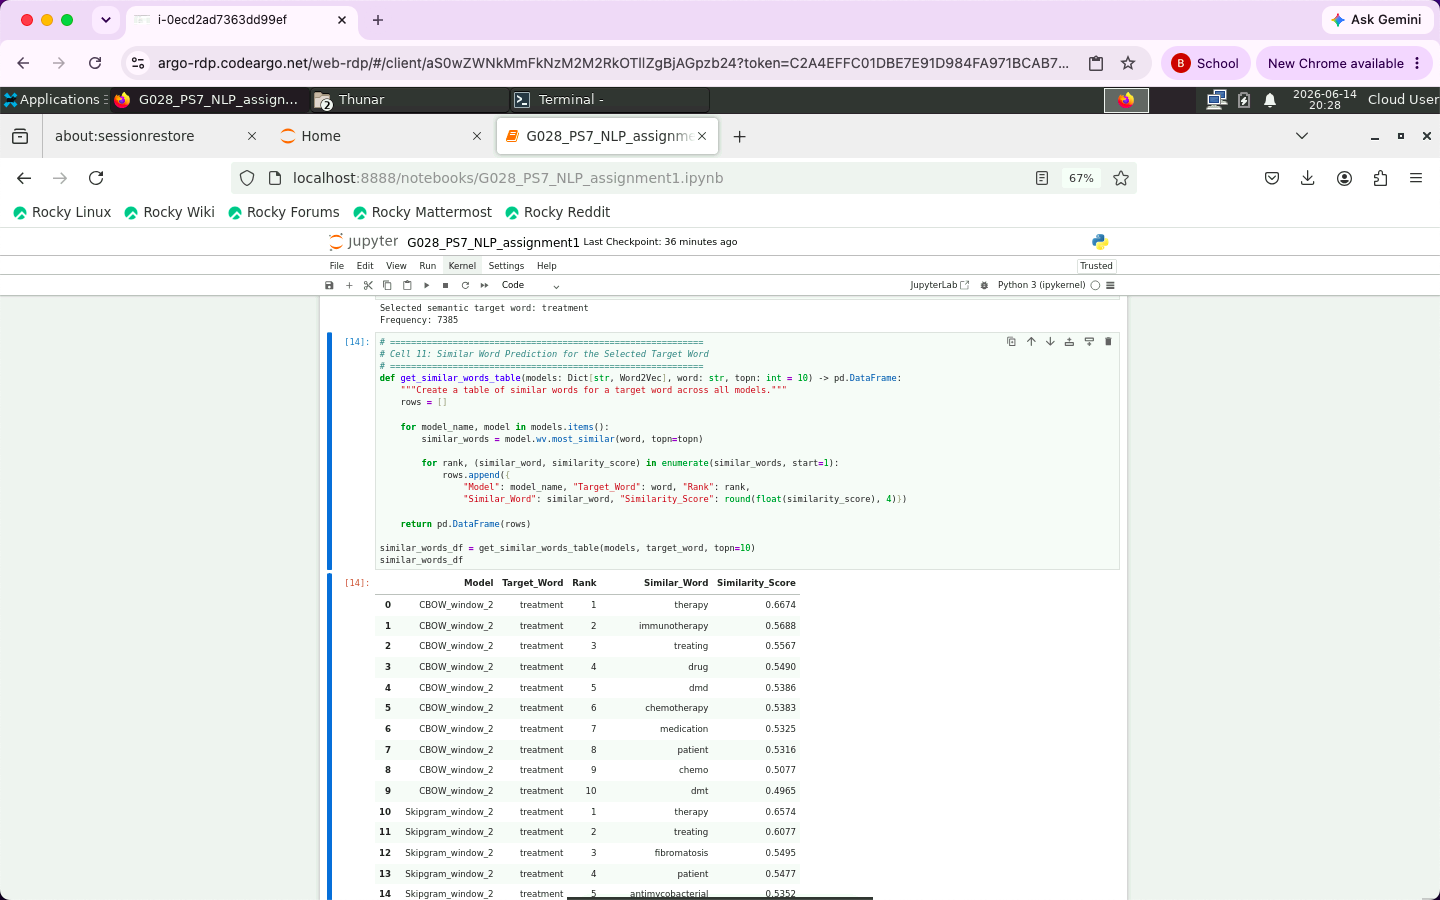

In [ ]:
from IPython.display import Image

Image(filename="G028_PS7_NLP_assignment1.png", width=1000)